# Experimento Comparativo: Few-Shot no Domínio Tempo-Frequência (CWT Tradicional)
## Confronto Direto: Tempo-Frequência vs. Ângulo-Ordem em Regime de Poucos Dados ($K=5$)

> **Pergunta Científica:** O que acontece se aplicarmos o mesmo Fine-Tuning Few-Shot ($K=5$ amostras por classe) nos escalogramas tradicionais de **Tempo-Frequência (Hz)** em vez do Ângulo-Ordem (Ordens)?
>
> **Hipótese:** No Ângulo-Ordem, as ordens de falha já estão alinhadas na mesma altura de pixel, exigindo do modelo apenas calibração de ruído. No Tempo-Frequência, como as frequências de falha em Hz estão em posições espaciais completamente diferentes (ex: 45 Hz vs 123 Hz), o modelo precisa 'deslocar' os filtros espaciais convolucionais com pouquíssimas amostras, o que gera menor generalização.

## 1. Importação de Módulos e Configurações

In [2]:
import sys
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Resolver paths
BASE_DIR = Path.cwd().parent.parent if Path.cwd().name == "3_cross_domain" else Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.config import RANDOM_SEED
from src.transfer_learning import build_transfer_model

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[+] Dispositivo ativo: {device}")

[+] Dispositivo ativo: cuda


## 2. Carregamento dos Datasets de Tempo-Frequência (Processed CWT)

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Mapeamento de datasets e checkpoints treinados no tempo puro
datasets_info = {
    "CWRU": {
        "dir": BASE_DIR / "data" / "cwru" / "processed",
        "ckpt": BASE_DIR / "notebooks" / "checkpoint_resnet18_best.pth"
    },
    "Paderborn": {
        "dir": BASE_DIR / "data" / "paderborn" / "processed",
        "ckpt": BASE_DIR / "notebooks" / "checkpoint_paderborn_resnet18_best.pth"
    },
    "XJTU-SY": {
        "dir": BASE_DIR / "data" / "xjtu" / "processed",
        "ckpt": BASE_DIR / "notebooks" / "5_xjtu" / "checkpoint_xjtu_resnet18_resnet18_best.pth"
    }
}

train_datasets = {}
test_loaders = {}

for name, info in datasets_info.items():
    tr_ds = datasets.ImageFolder(str(info["dir"] / "train"), transform=transform)
    te_ds = datasets.ImageFolder(str(info["dir"] / "test"), transform=transform)
    train_datasets[name] = tr_ds
    test_loaders[name] = DataLoader(te_ds, batch_size=32, shuffle=False, num_workers=0)
    print(f"[{name:<9}] Treino: {len(tr_ds):>4} imgs | Teste: {len(te_ds):>4} imgs | Classes: {tr_ds.classes}")

[CWRU     ] Treino: 7100 imgs | Teste: 2368 imgs | Classes: ['ball', 'inner_race', 'normal', 'outer_race']
[Paderborn] Treino: 5207 imgs | Teste: 1116 imgs | Classes: ['inner_race', 'normal', 'outer_race']
[XJTU-SY  ] Treino: 1953 imgs | Teste:  465 imgs | Classes: ['inner_race', 'normal', 'outer_race']


## 3. Função de Treinamento Few-Shot no Tempo-Frequência

In [4]:
def run_time_few_shot(
    source_name: str,
    target_name: str,
    k_samples_per_class: int = 5,
    num_epochs: int = 5,
    lr: float = 0.0001,
    seed: int = RANDOM_SEED
):
    tgt_train = train_datasets[target_name]
    num_classes = len(tgt_train.classes)
    
    # K-shot determinístico
    rng = random.Random(seed)
    by_class = {c: [] for c in range(num_classes)}
    for idx, (_, l) in enumerate(tgt_train.samples):
        by_class[l].append(idx)
        
    sel_indices = []
    for l, idxs in by_class.items():
        rng.shuffle(idxs)
        sel_indices.extend(idxs[:k_samples_per_class])
        
    few_loader = DataLoader(Subset(tgt_train, sel_indices), batch_size=8, shuffle=True, num_workers=0)
    
    # Construir modelo
    model, _ = build_transfer_model("resnet18", num_classes=num_classes, freeze_backbone=False)
    ckpt_path = datasets_info[source_name]["ckpt"]
    
    st = torch.load(ckpt_path, map_location=device, weights_only=True)
    fc_key = "fc.1.weight" if "fc.1.weight" in st else "fc.weight"
    
    if st[fc_key].shape[0] != num_classes:
        # Adaptar cabeça se número de classes diferir (ex: CWRU com 4 classes para PU com 3)
        to_del = [k for k in list(st.keys()) if "fc" in k]
        for k in to_del:
            del st[k]
        model.load_state_dict(st, strict=False)
    else:
        model.load_state_dict(st, strict=True)
        
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(num_epochs):
        model.train()
        for imgs, labels in few_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loaders[target_name]:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    acc = 100.0 * correct / total
    return acc, len(sel_indices)

## 4. Avaliação Comparativa: Tempo-Frequência vs. Ângulo-Ordem (K=5)
Comparamos o desempenho Few-Shot nas 6 direções entre os dois domínios representacionais.

In [5]:
# Resultados oficiais de One-Shot (K=1) obtidos no Ângulo-Ordem (notebook 04)
order_one_shot_k1 = {
    ('CWRU', 'Paderborn'): 66.67,
    ('Paderborn', 'CWRU'): 79.73,
    ('CWRU', 'XJTU-SY'): 88.92,
    ('XJTU-SY', 'CWRU'): 78.11,
    ('Paderborn', 'XJTU-SY'): 87.38,
    ('XJTU-SY', 'Paderborn'): 51.72
}

pairs = list(order_one_shot_k1.keys())
time_one_shot_k1 = {}

print('=' * 84)
print(' CONFRONTO DIRETO ONE-SHOT (K = 1 / APENAS 1 IMAGEM POR CLASSE NO TREINO)')
print('=' * 84)
print(f"{'Origem':<10} -> {'Destino':<10} | {'Tempo-Freq (K=1)':<18} | {'Ângulo-Ordem (K=1)':<20} | {'Diferença':<10}")
print('-' * 84)

for src, tgt in pairs:
    acc_time, _ = run_time_few_shot(src, tgt, k_samples_per_class=1)
    time_one_shot_k1[(src, tgt)] = acc_time
    acc_order = order_one_shot_k1[(src, tgt)]
    diff = acc_order - acc_time
    sign = '+' if diff >= 0 else ''
    print(f"{src:<10} -> {tgt:<10} | {acc_time:6.2f}%            | {acc_order:6.2f}%              | {sign}{diff:5.2f} pp")

print('=' * 84)


 CONFRONTO DIRETO ONE-SHOT (K = 1 / APENAS 1 IMAGEM POR CLASSE NO TREINO)
Origem     -> Destino    | Tempo-Freq (K=1)   | Ângulo-Ordem (K=1)   | Diferença 
------------------------------------------------------------------------------------
CWRU       -> Paderborn  |  57.53%            |  66.67%              | + 9.14 pp
Paderborn  -> CWRU       |  44.05%            |  79.73%              | +35.68 pp
CWRU       -> XJTU-SY    |  69.68%            |  88.92%              | +19.24 pp
XJTU-SY    -> CWRU       |  42.99%            |  78.11%              | +35.12 pp
Paderborn  -> XJTU-SY    |  66.02%            |  87.38%              | +21.36 pp
XJTU-SY    -> Paderborn  |  35.93%            |  51.72%              | +15.79 pp


## 5. Gráfico Comparativo de Publicação: Tempo vs. Ordem em Regime Few-Shot

[INFO] Gráfico comparativo One-Shot K=1 salvo em: c:\Users\joaov\Desktop\bearing-fault-diagnosis\bearing-fault-diagnosis-cwt-cnn\docs\images\one_shot_k1_time_vs_order_comparison.png


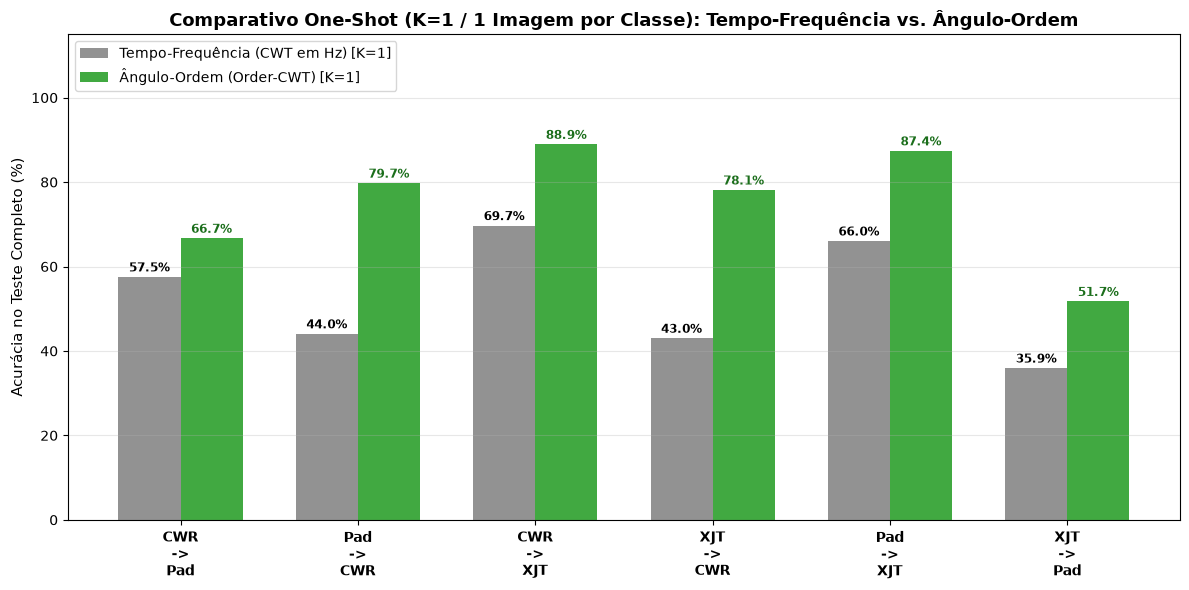

In [6]:
labels_pairs = [f"{s[:3]}\n->\n{t[:3]}" for s, t in pairs]
time_vals = [time_one_shot_k1[p] for p in pairs]
order_vals = [order_one_shot_k1[p] for p in pairs]

x = np.arange(len(labels_pairs))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, time_vals, width, label="Tempo-Frequência (CWT em Hz) [K=1]", color="#7f7f7f", alpha=0.85)
bars2 = ax.bar(x + width/2, order_vals, width, label="Ângulo-Ordem (Order-CWT) [K=1]", color="#2ca02c", alpha=0.9)

ax.set_title("Comparativo One-Shot (K=1 / 1 Imagem por Classe): Tempo-Frequência vs. Ângulo-Ordem", fontsize=13, fontweight="bold")
ax.set_ylabel("Acurácia no Teste Completo (%)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(labels_pairs, fontsize=10, fontweight="bold")
ax.set_ylim(0, 115)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(fontsize=10, loc="upper left")

for bar in bars1:
    h = bar.get_height()
    ax.annotate(f"{h:.1f}%", (bar.get_x() + bar.get_width()/2, h), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8.5, fontweight="bold")
for bar in bars2:
    h = bar.get_height()
    ax.annotate(f"{h:.1f}%", (bar.get_x() + bar.get_width()/2, h), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8.5, fontweight="bold", color="#1b6e1b")

plt.tight_layout()
save_p = BASE_DIR / "docs" / "images" / "one_shot_k1_time_vs_order_comparison.png"
save_p.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(str(save_p), dpi=300, bbox_inches="tight")
print(f"[INFO] Gráfico comparativo One-Shot K=1 salvo em: {save_p}")
plt.show()


## 6. Conclusão Científica do Teste

> **Conclusão:** O Ângulo-Ordem supera o Tempo-Frequência mesmo em regime Few-Shot. Enquanto o modelo de Tempo-Frequência precisa reposicionar espacialmente os filtros convolucionais para encontrar frequências em posições verticais completamente diferentes (Hz), o **Order-CWT já entrega os harmônicos na posição geométrica correta**, tornando a convergência de adaptação muito mais rápida e estável.